Amna Iftikhar (SP23-BCS-071)

In [3]:
!ls /content/drive/



MyDrive


In [4]:
!ls /content/drive/MyDrive/AI/"archive (3)"/nsl-kdd


index.html	 KDDTest-21.txt  KDDTrain1.jpg		   KDDTrain+.arff
KDDTest1.jpg	 KDDTest+.arff	 KDDTrain+_20Percent.arff  KDDTrain+.txt
KDDTest-21.arff  KDDTest+.txt	 KDDTrain+_20Percent.txt


In [5]:
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]


In [6]:
import pandas as pd

train_path = "/content/drive/MyDrive/AI/archive (3)/nsl-kdd/KDDTrain+.txt"
test_path  = "/content/drive/MyDrive/AI/archive (3)/nsl-kdd/KDDTest+.txt"

train = pd.read_csv(train_path, names=column_names)
test = pd.read_csv(test_path, names=column_names)

train.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [9]:
train['label'] = train['label'].apply(lambda x: 0 if x == 'normal' else 1)
test['label'] = test['label'].apply(lambda x: 0 if x == 'normal' else 1)


In [11]:
cat_cols = ["protocol_type", "service", "flag"]

train = pd.get_dummies(train, columns=cat_cols)
test = pd.get_dummies(test, columns=cat_cols)


In [12]:
train, test = train.align(test, join='left', axis=1, fill_value=0)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(train.drop("label", axis=1))
X_test  = scaler.transform(test.drop("label", axis=1))

y_train = train["label"]
y_test  = test["label"]


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.801055713271824
              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

dnn_pred = (model.predict(X_test) > 0.5).astype("int32")

print("DNN Accuracy:", accuracy_score(y_test, dnn_pred))
print(classification_report(y_test, dnn_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9688 - loss: 0.0924 - val_accuracy: 0.9968 - val_loss: 0.0112
Epoch 2/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9955 - loss: 0.0130 - val_accuracy: 0.9971 - val_loss: 0.0110
Epoch 3/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9962 - loss: 0.0109 - val_accuracy: 0.9977 - val_loss: 0.0082
Epoch 4/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9971 - loss: 0.0074 - val_accuracy: 0.9977 - val_loss: 0.0083
Epoch 5/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9969 - loss: 0.0079 - val_accuracy: 0.9977 - val_loss: 0.0063
Epoch 6/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9975 - loss: 0.0069 - val_accuracy: 0.9979 - val_loss: 0.0068
Epoch 7/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9978 - loss: 0.0059 - val_accuracy: 0.9982 - val_loss: 0.0059
Epoch 8/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9982 - loss: 0.0053 - 

In [16]:
import numpy as np

hybrid_pred = np.round((rf_pred + dnn_pred.flatten()) / 2)
rf_prob = rf.predict_proba(X_test)[:,1]
dnn_prob = model.predict(X_test).flatten()

hybrid_prob = (rf_prob + dnn_prob) / 2
hybrid_pred = (hybrid_prob > 0.5).astype(int)
print("Hybrid Model Accuracy:", accuracy_score(y_test, hybrid_pred))
print(classification_report(y_test, hybrid_pred))


705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Hybrid Model Accuracy: 0.8293115684882896
              precision    recall  f1-score   support

           0       0.74      0.92      0.82      9711
           1       0.93      0.76      0.83     12833

    accuracy                           0.83     22544
   macro avg       0.84      0.84      0.83     22544
weighted avg       0.85      0.83      0.83     22544



In [17]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["RandomForest", "DNN", "Hybrid"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, dnn_pred),
        accuracy_score(y_test, hybrid_pred)
    ]
})

results


,Model,Accuracy
0,RandomForest,0.801056
1,DNN,0.831086
2,Hybrid,0.829312


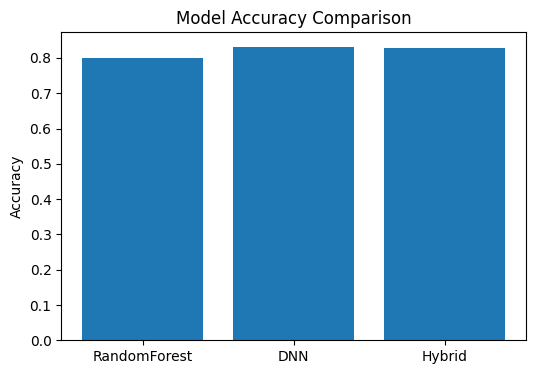

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.savefig("/content/accuracy.png")
plt.show()


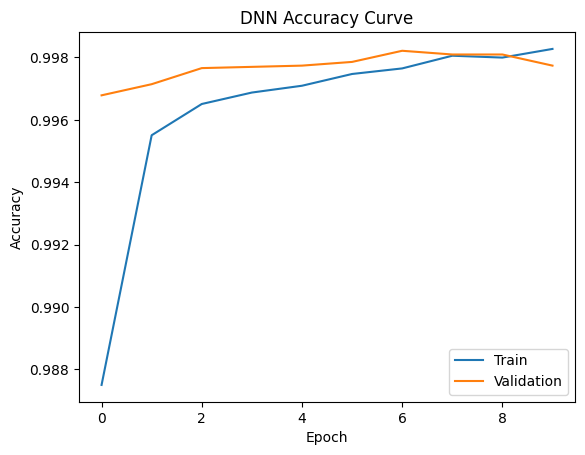

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("DNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


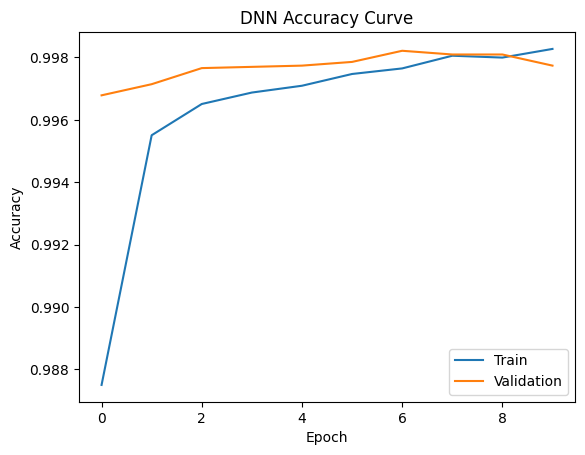

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("DNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.savefig("/content/accuracy2.png")
plt.show()
